# ASSIGNMENT 3: Pulse of Prevention: Analyzing Heart Health for Better Outcomes

# IMPORTING LIRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTING DATASET

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Basic Dataset Inspection

In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Data Cleaning

### Step 1: Check Missing Values

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

All columns have 0 missing values.

- The dataset is complete.
- No imputation is required.
- No rows or columns need to be removed due to missing data.

### Step 2: Check Duplicate Records

In [8]:
df.duplicated().sum()

np.int64(723)

This is a very large number of duplicates (about 70% of the dataset), so we should remove them before proceeding with analysis.

In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(302, 14)

- 723 duplicate records were successfully removed.
- Dataset size reduced from 1025 → 302 rows.
- We will use this deduplicated dataset for all further analysis.

### Step 3: Data Type Validation

In [11]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

- All columns have appropriate numeric data types.
- No column is stored as object or string.
- oldpeak is correctly stored as float64.
- All remaining features are correctly stored as int64.

### Step 4: Outlier Detection

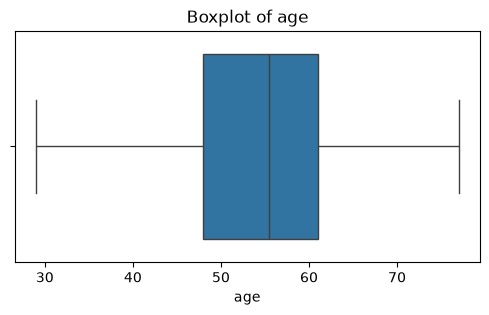

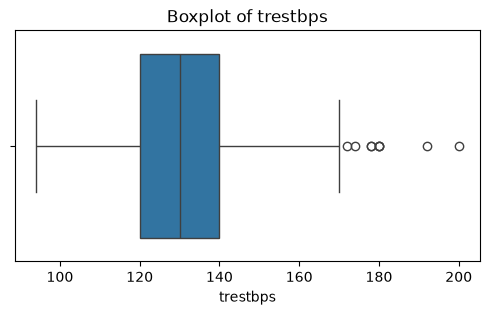

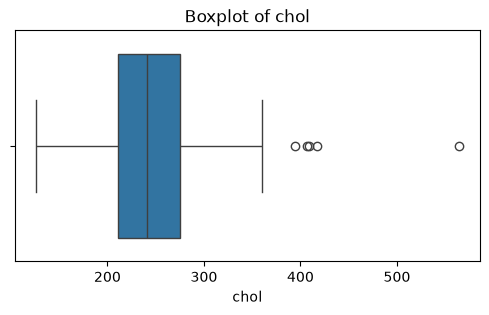

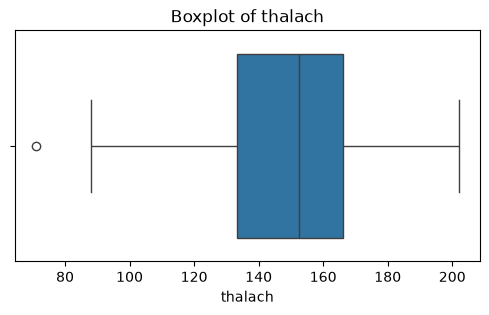

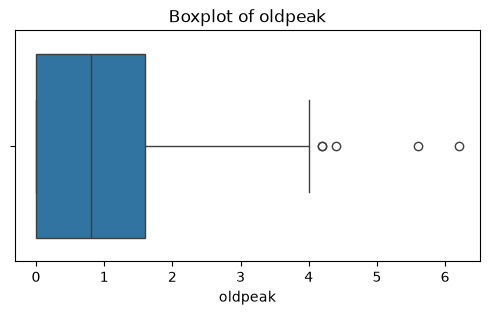

In [12]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

**Observation from Boxplots**

- age: No significant outliers
- trestbps: Few high-value outliers
- chol: Few high-value outliers
- thalach: One low-value outlier
- oldpeak: Few high-value outliers

For a healthcare dataset, these values can represent real patients with genuine medical conditions, not necessarily data entry errors.

**For this EDA project:**

Keep the outliers

Reason:

- They are clinically meaningful observations.
- Removing them may hide important high-risk patient patterns.
- We are performing Exploratory Data Analysis, not building a predictive model where aggressive outlier treatment might be considered.

**Conclusion**
- Outliers detected in a few numerical columns.
- No evidence of invalid or impossible values.
- Outliers retained for analysis.

### Step 5: Data Normalization

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Data Cleaning Summary

~95% of the data cleaning is complete.

Completed Cleaning Tasks

✅ Duplicate Records Removed (723 duplicate rows removed)

✅ Missing Values Checked (No missing values found)

✅ Data Types Validated (All columns have appropriate data types)

✅ Numerical Features Reviewed

✅ Outlier Detection Performed

✅ Clinically Valid Outliers Retained

✅ Dataset Consistency Verified

✅ Dataset Reduced from 1025 → 302 Unique Records

✅ Clean Dataset Created (df_cleaned)

✅ Dataset Ready for Exploratory Data Analysis (EDA)

In [14]:
df_cleaned = df.copy()

In [15]:
df_cleaned.to_csv('heart_cleaned.csv', index=False)

# BASIC LEVEL QUESTIONS

## 1. What is the average age of patients in the dataset?

In [16]:
avg_age = df_cleaned['age'].mean()
print(f"Average Age: {avg_age:.2f} years")

Average Age: 54.42 years


### Visualization

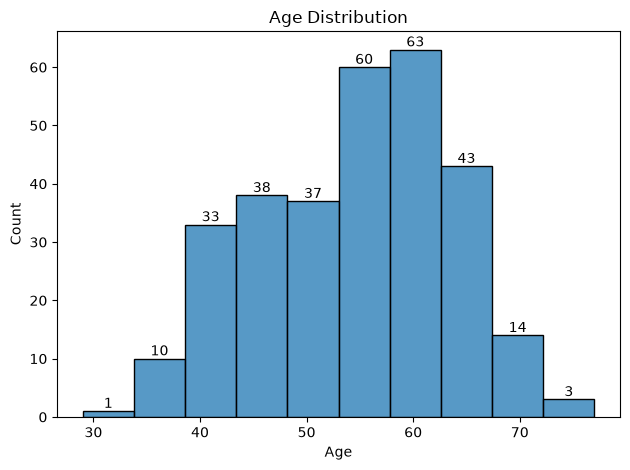

In [17]:
ax = sns.histplot(
    df_cleaned['age'],
    bins=10
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Business Insight**

- Patients in their mid-50s represent the typical demographic in the dataset.
- Healthcare providers can prioritize screening and preventive care programs for individuals aged 50 years and above.
- Early lifestyle interventions in the 40–50 age group may help reduce future heart disease risk.

**Conclusion**

- The average patient age is 54.42 years.
- Most patients fall within the middle-aged to senior age category.

## 2. What is the gender distribution of patients?

In [18]:
gender_counts = df_cleaned['sex'].replace({0:'Female', 1:'Male'}).value_counts()

print(gender_counts)

sex
Male      206
Female     96
Name: count, dtype: int64


### Visualization

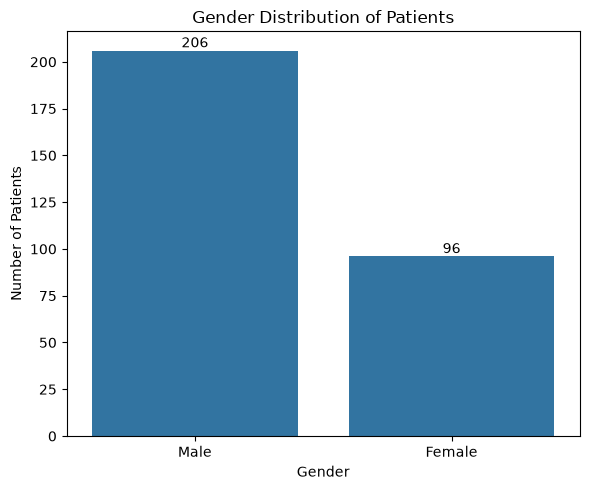

In [19]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x=df_cleaned['sex'].replace({0:'Female', 1:'Male'})
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Gender Distribution of Patients')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

**Business Insight**

- The higher proportion of male patients suggests that men may be more likely to undergo heart disease evaluation or may have a higher occurrence of cardiovascular risk factors in this dataset.
- Healthcare organizations can design targeted awareness campaigns and preventive screening programs for men while ensuring women are not under-screened.
- Understanding gender differences can help providers develop more personalized prevention and treatment strategies.

**Conclusion**

- The dataset consists of 206 male patients and 96 female patients.
- Males represent approximately 68% of the patient population, while females represent approximately 32%.

## 3. What is the average resting blood pressure of patients?

In [20]:
avg_bp = df_cleaned['trestbps'].mean()

print(f"Average Resting Blood Pressure: {avg_bp:.2f} mmHg")

Average Resting Blood Pressure: 131.60 mmHg


### Visualization

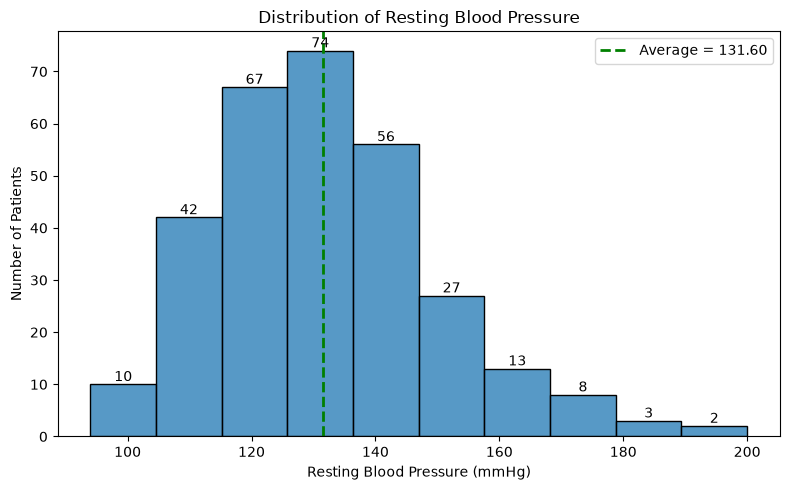

In [21]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    df_cleaned['trestbps'],
    bins=10
)

for container in ax.containers:
    ax.bar_label(container)

plt.axvline(
    avg_bp,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Average = {avg_bp:.2f}'
)

plt.title('Distribution of Resting Blood Pressure')
plt.xlabel('Resting Blood Pressure (mmHg)')
plt.ylabel('Number of Patients')
plt.legend()

plt.tight_layout()
plt.show()

**Business Insight**

- An average resting blood pressure of 131.60 mmHg is slightly above the ideal normal blood pressure range (<120/80 mmHg), suggesting that many patients may be at an elevated cardiovascular risk.
- Healthcare providers can use this information to identify patients who may benefit from blood pressure monitoring, lifestyle modifications, and early intervention programs.
- Regular screening and hypertension management initiatives can help reduce the likelihood of heart-related complications and emergency hospitalizations.

**Conclusion**

- The average resting blood pressure of patients is 131.60 mmHg.
- Most patients have resting blood pressure values between 120 and 145 mmHg.
- The presence of several patients with notably high blood pressure highlights the importance of hypertension management as part of heart disease prevention strategies.

## 4. How many patients have fasting blood sugar levels higher than 120 mg/dl?

In [22]:
high_fbs_count = df_cleaned['fbs'].sum()

print(f"Patients with Fasting Blood Sugar > 120 mg/dl: {high_fbs_count}")

Patients with Fasting Blood Sugar > 120 mg/dl: 45


### Visualization

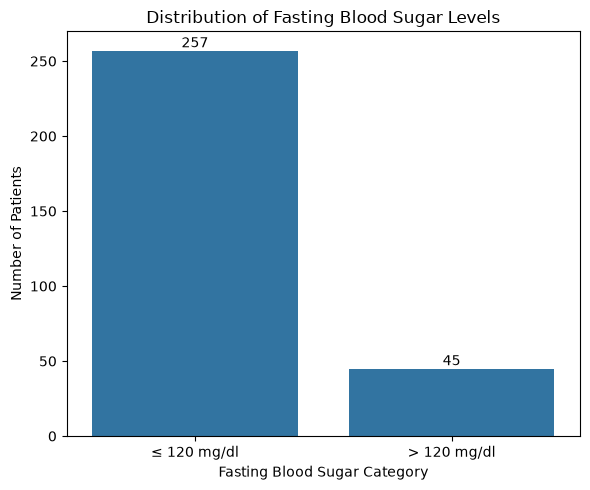

In [23]:
fbs_counts = df_cleaned['fbs'].replace(
    {0: '≤ 120 mg/dl', 1: '> 120 mg/dl'}
).value_counts()

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=fbs_counts.index,
    y=fbs_counts.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Fasting Blood Sugar Levels')
plt.xlabel('Fasting Blood Sugar Category')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

**Business Insight**

- High fasting blood sugar is often associated with diabetes and metabolic disorders, which are known contributors to cardiovascular disease.
- Identifying these 45 high-risk patients allows healthcare providers to recommend personalized dietary plans, physical activity programs, and regular glucose monitoring.
- Early intervention for patients with elevated blood sugar can help reduce the risk of heart disease progression and lower long-term healthcare costs.

**Conclusion**

- 45 patients in the dataset have fasting blood sugar levels greater than 120 mg/dl.
- Although they represent a minority of the patient population, they constitute an important high-risk group for cardiovascular complications.

## 5. What are the different types of chest pain recorded in the dataset?

In [24]:
cp_counts = df_cleaned['cp'].value_counts().sort_index()

print(cp_counts)

cp
0    143
1     50
2     86
3     23
Name: count, dtype: int64


Chest Pain Type Meaning

- 0: Typical Angina
- 1: Atypical Angina
- 2:Non-Anginal Pain
- 3: Asymptomatic

### Visualization

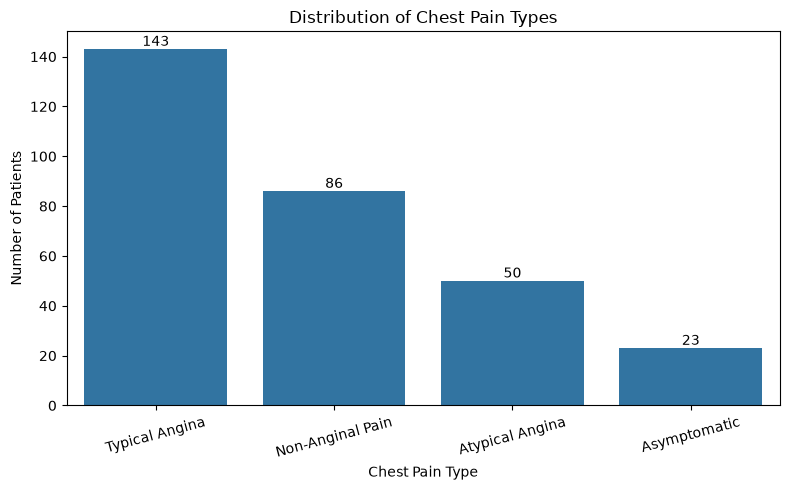

In [25]:
cp_labels = {
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-Anginal Pain',
    3: 'Asymptomatic'
}

cp_counts = df_cleaned['cp'].map(cp_labels).value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=cp_counts.index,
    y=cp_counts.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Chest Pain Types')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**Business Insight**

- Chest pain type is one of the most important indicators used in cardiovascular diagnosis.
- The high number of patients with Typical Angina suggests that many patients exhibit symptoms commonly associated with reduced blood flow to the heart.
- Healthcare providers can prioritize patients presenting with angina-related symptoms for further diagnostic evaluation and monitoring.
- Understanding the distribution of chest pain types helps hospitals allocate resources efficiently and develop symptom-specific treatment strategies.

**Conclusion**

- The dataset contains four chest pain categories: Typical Angina, Atypical Angina, Non-Anginal Pain, and Asymptomatic.
- Typical Angina is the most prevalent type, accounting for 143 patients (47.35%).

## 6. What is the maximum heart rate achieved by patients?

In [26]:
max_hr = df_cleaned['thalach'].max()

print(f"Maximum Heart Rate Achieved: {max_hr} bpm")

Maximum Heart Rate Achieved: 202 bpm


### Visualization

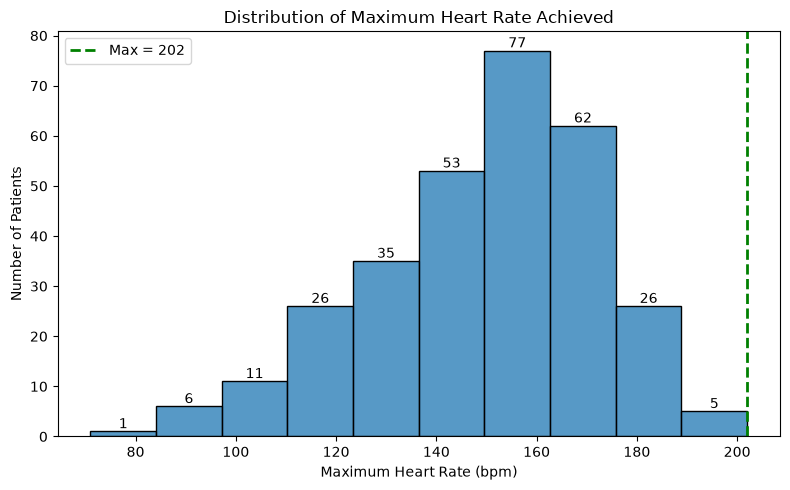

In [27]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    df_cleaned['thalach'],
    bins=10
)

for container in ax.containers:
    ax.bar_label(container)

plt.axvline(
    max_hr,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Max = {max_hr}'
)

plt.title('Distribution of Maximum Heart Rate Achieved')
plt.xlabel('Maximum Heart Rate (bpm)')
plt.ylabel('Number of Patients')
plt.legend()

plt.tight_layout()
plt.show()

**Business Insight**

- Maximum heart rate is an important indicator of cardiovascular performance and exercise tolerance.
- Patients who achieve higher heart rates may demonstrate better cardiovascular responsiveness, while lower values may indicate exercise limitations or underlying cardiac conditions.
- Understanding heart rate distribution helps healthcare providers develop personalized fitness, rehabilitation, and monitoring programs.
- Knowledge of the upper heart rate limits can also support safer exercise prescriptions and reduce the risk of adverse cardiac events during physical activity.

**Conclusion**

- The maximum heart rate achieved by patients is 202 bpm.
- Most patients recorded maximum heart rates between 140 bpm and 175 bpm.
- The heart rate distribution indicates substantial variation in cardiovascular performance across patients.

## 7. What percentage of patients experience exercise-induced angina?

In [28]:
angina_percentage = df_cleaned['exang'].mean() * 100

print(f"Percentage of Patients with Exercise-Induced Angina: {angina_percentage:.2f}%")

Percentage of Patients with Exercise-Induced Angina: 32.78%


### Counts

In [29]:
exang_counts = df_cleaned['exang'].value_counts()

print(exang_counts)

exang
0    203
1     99
Name: count, dtype: int64


**Category Meaning**
- 0: No Exercise-Induced Angina
- 1: Exercise-Induced Angina Present

### Visualization

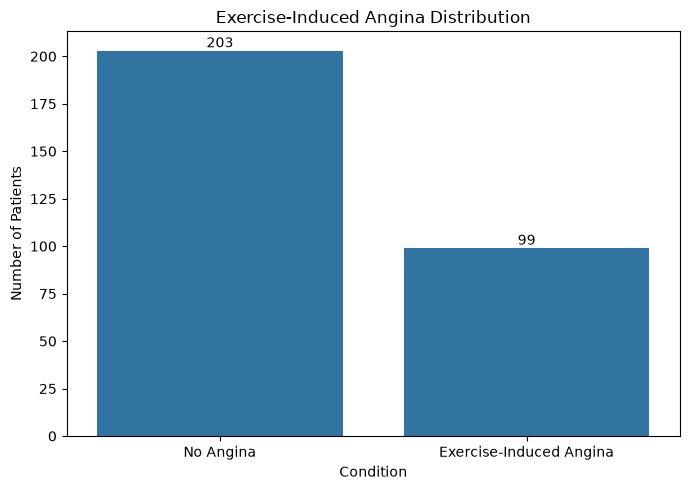

In [30]:
exang_counts = df_cleaned['exang'].replace({
    0: 'No Angina',
    1: 'Exercise-Induced Angina'
}).value_counts()

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=exang_counts.index,
    y=exang_counts.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Exercise-Induced Angina Distribution')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

**Business Insight**

- Exercise-induced angina is an important warning sign of underlying cardiovascular disease and reduced blood flow to the heart.
- The presence of angina in nearly 33% of patients indicates a substantial group that may require specialized monitoring and exercise recommendations.
- Healthcare providers can use this information to create personalized rehabilitation and fitness programs that minimize cardiovascular risk.
- Early identification of patients prone to exercise-induced angina can help prevent complications and improve long-term patient outcomes.

**Conclusion**

- 32.78% of patients experience exercise-induced angina, while 67.22% do not.
- This indicates that a significant portion of the patient population experiences chest pain during physical exertion.
- Exercise-induced angina should be considered an important risk indicator when assessing cardiovascular health and designing preventive care strategies.

## 8. What is the average cholesterol level in the dataset?

In [31]:
avg_chol = df_cleaned['chol'].mean()

print(f"Average Cholesterol Level: {avg_chol:.2f} mg/dl")

Average Cholesterol Level: 246.50 mg/dl


### Visualization

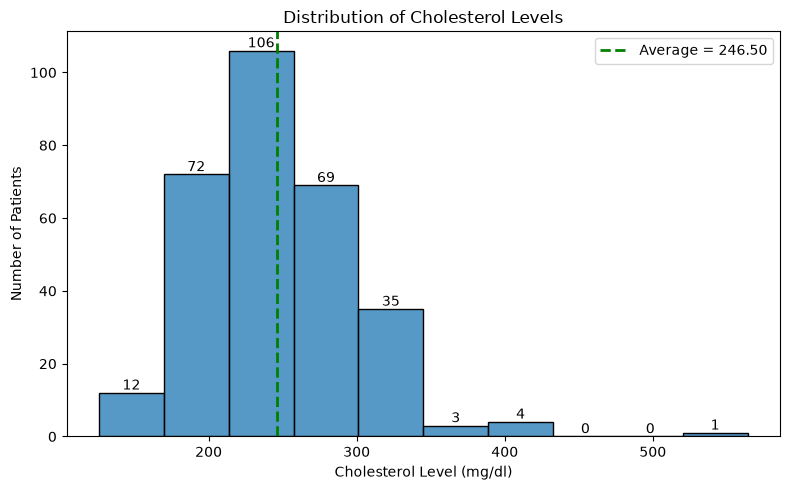

In [32]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    df_cleaned['chol'],
    bins=10
)

for container in ax.containers:
    ax.bar_label(container)

plt.axvline(
    avg_chol,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Average = {avg_chol:.2f}'
)

plt.title('Distribution of Cholesterol Levels')
plt.xlabel('Cholesterol Level (mg/dl)')
plt.ylabel('Number of Patients')
plt.legend()

plt.tight_layout()
plt.show()

**Business Insight**

- Cholesterol is a major risk factor for cardiovascular disease because elevated levels can contribute to plaque buildup in arteries.
- The average cholesterol level of 246.50 mg/dl is above the generally recommended total cholesterol level of 200 mg/dl, suggesting that many patients may be at increased cardiovascular risk.
- Healthcare providers can use this information to identify patients who may benefit from dietary counseling, cholesterol-lowering medications, and regular lipid profile monitoring.
- Targeted cholesterol management programs can help reduce heart disease incidence and lower long-term treatment costs.

**Conclusion**

- The average cholesterol level in the dataset is 246.50 mg/dl.
- Most patients have cholesterol levels ranging from 200 mg/dl to 300 mg/dl.
- Several patients exhibit exceptionally high cholesterol levels, indicating the presence of a high-risk subgroup.

## 9. How many patients have a resting electrocardiographic result of 2?

In [33]:
restecg_counts = df_cleaned['restecg'].value_counts().sort_index()

print(restecg_counts)

restecg
0    147
1    151
2      4
Name: count, dtype: int64


### Count

In [34]:
ecg_result_2 = (df_cleaned['restecg'] == 2).sum()

print(f"Patients with Resting ECG Result = 2: {ecg_result_2}")

Patients with Resting ECG Result = 2: 4


**Resting ECG Meaning**

- 0: Normal
- 1: ST-T Wave Abnormality
- 2: Left Ventricular Hypertrophy (LVH)

### Visualization

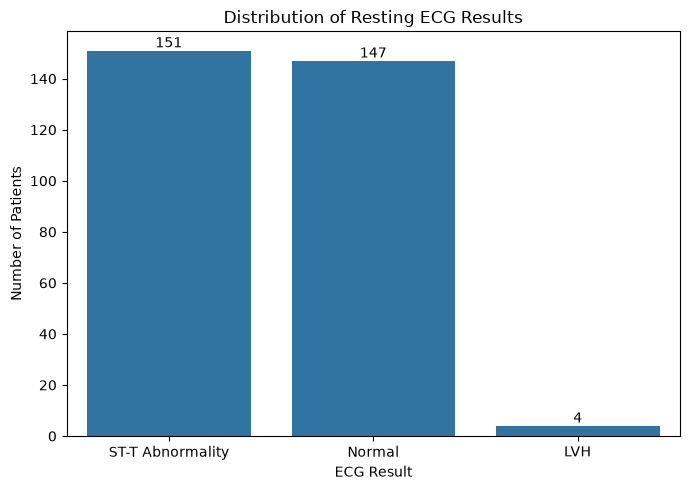

In [35]:
ecg_labels = {
    0: 'Normal',
    1: 'ST-T Abnormality',
    2: 'LVH'
}

ecg_counts = df_cleaned['restecg'].map(ecg_labels).value_counts()

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=ecg_counts.index,
    y=ecg_counts.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Resting ECG Results')
plt.xlabel('ECG Result')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

**Business Insight**

- Resting ECG tests help identify abnormalities in heart function and structure before severe symptoms develop.
- The 4 patients with LVH represent a high-risk group that may require additional cardiac evaluation and monitoring.
- Since 50% of patients show ST-T abnormalities, healthcare providers may need to investigate potential underlying cardiovascular issues in a substantial portion of the population.
- Early detection through ECG screening can support preventive treatment plans and reduce the likelihood of serious cardiac events.

**Conclusion**

- 4 patients have a resting ECG result of 2 (Left Ventricular Hypertrophy).
- While this represents only 1.32% of the dataset, LVH is an important clinical finding linked to increased cardiovascular risk.
- The dataset also shows a high prevalence of ST-T wave abnormalities (50%), highlighting the importance of ECG-based screening in patient assessment.

## 10. What is the distribution of the number of major vessels colored by fluoroscopy?

In [36]:
ca_counts = df_cleaned['ca'].value_counts().sort_index()

print(ca_counts)

ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64


**Meaning of ca**

- 0: No major vessels colored
- 1: One major vessel colored
- 2: Two major vessels colored
- 3: Three major vessels colored
- 4: Four major vessels colored

### Visualization

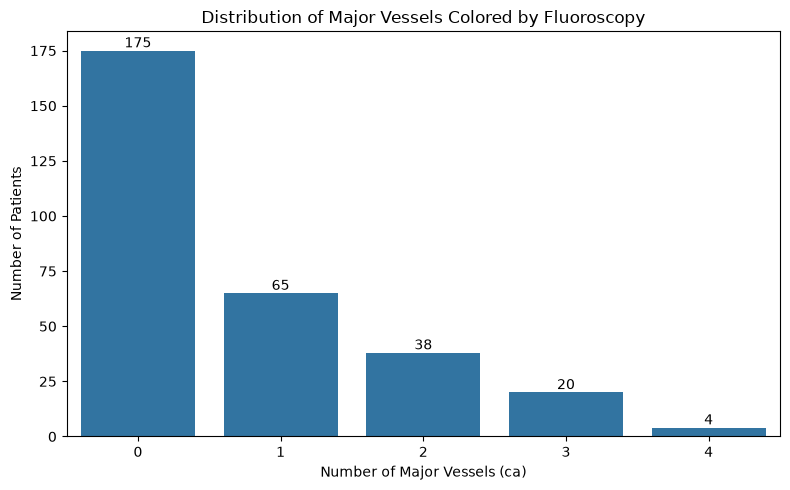

In [37]:
ca_counts = df_cleaned['ca'].value_counts().sort_index()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=ca_counts.index,
    y=ca_counts.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Major Vessels Colored by Fluoroscopy')
plt.xlabel('Number of Major Vessels (ca)')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

**Business Insight**

- The number of major vessels identified through fluoroscopy is a key indicator of coronary artery disease severity.
- Patients with higher ca values (2, 3, or 4) may require more intensive monitoring, advanced diagnostic procedures, or specialized treatment plans.
- Since nearly 42% of patients show involvement of one or more major vessels, cardiovascular screening remains critical for this population.
- Healthcare providers can use this information to prioritize high-risk patients and optimize resource allocation for cardiac care.

**Conclusion**

- The most common finding is 0 major vessels involved, accounting for 57.95% of patients.
- A smaller but clinically significant group shows involvement of multiple vessels, which may indicate more advanced coronary artery disease.
- The decreasing trend across increasing vessel counts suggests that severe vessel involvement is less common but potentially more critical.

# MID LEVEL QUESTIONS

## 1. What is the correlation between age and cholesterol levels?

In [38]:
correlation = df_cleaned[['age', 'chol']].corr()

print(correlation)

           age      chol
age   1.000000  0.207216
chol  0.207216  1.000000


Correlation (Age vs Cholesterol) = 0.207

- 0.207: Weak Positive Correlation

### Visualization

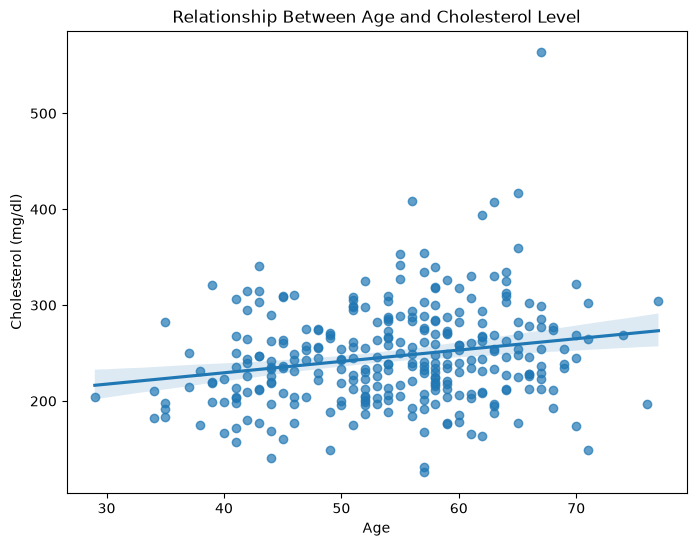

In [39]:
plt.figure(figsize=(8,6))

sns.regplot(
    x='age',
    y='chol',
    data=df_cleaned,
    scatter_kws={'alpha':0.7}
)

plt.title('Relationship Between Age and Cholesterol Level')
plt.xlabel('Age')
plt.ylabel('Cholesterol (mg/dl)')

plt.show()

**Business Insight**

- Since cholesterol tends to increase slightly with age, healthcare providers should encourage more frequent cholesterol screenings for middle-aged and older adults.
- However, the weak correlation indicates that age should not be used as the sole predictor of cholesterol risk.
- Preventive programs should consider additional factors such as diet, physical activity, obesity, diabetes, smoking habits, and family history.
- Age-specific wellness initiatives combined with comprehensive cardiovascular risk assessments can improve early detection and intervention.

**Conclusion**

- There is a weak positive correlation (0.207) between age and cholesterol levels.
- Cholesterol levels show a slight tendency to rise with increasing age, but the relationship is not strong.
- Age contributes to cholesterol variation, but other clinical and lifestyle factors likely have a greater influence.

## 2. What is the distribution of chest pain types across different age groups?

### Create Age Group

In [40]:
df_cleaned['Age_Group'] = pd.cut(
    df_cleaned['age'],
    bins=[0, 40, 50, 60, 70, 100],
    labels=['<40', '40-50', '50-60', '60-70', '70+']
)

### Visualization

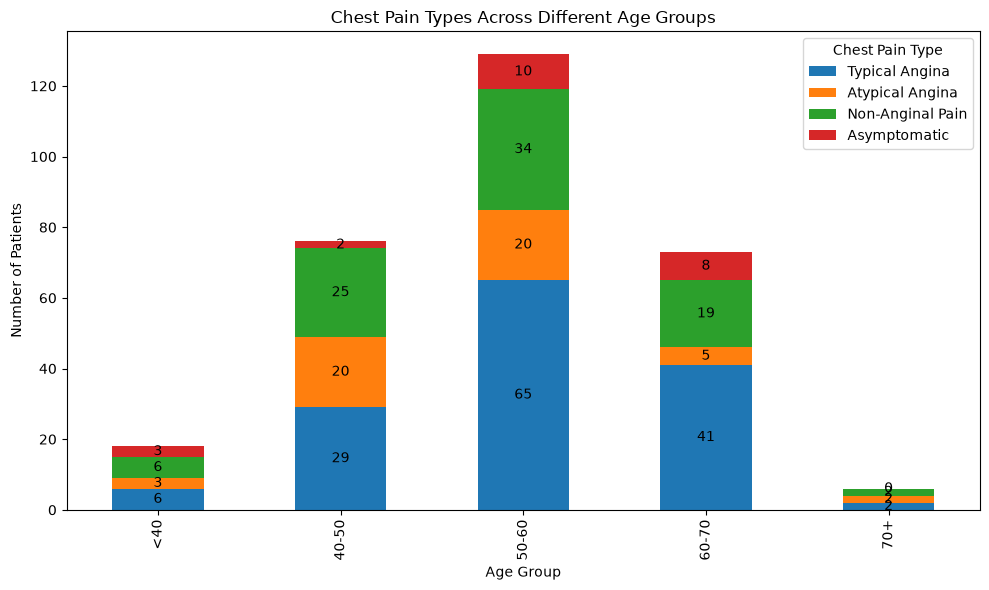

In [41]:
cp_age = df_cleaned.groupby('Age_Group')['cp'].value_counts().unstack(fill_value=0)

ax = cp_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.title('Chest Pain Types Across Different Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(
    title='Chest Pain Type',
    labels=['Typical Angina','Atypical Angina','Non-Anginal Pain','Asymptomatic']
)

plt.tight_layout()
plt.show()

**Chest Pain Type Meaning**

- 0: Typical Angina
- 1: Atypical Angina
- 2: Non-Anginal Pain
- 3: Asymptomatic

**Business Insight**

- Patients aged 50–60 years represent the largest concentration of heart-related chest pain symptoms and should be considered a key target group for preventive cardiovascular programs.
- Since Typical Angina dominates across age groups, healthcare providers can prioritize screening protocols for patients presenting with classic angina symptoms.
- The presence of significant Non-Anginal Pain cases suggests that heart disease symptoms are not always typical, highlighting the need for comprehensive diagnostic evaluations.
- Age-specific symptom patterns can help hospitals and clinics optimize diagnostic workflows, patient triage, and resource allocation.

**Conclusion**

- The 50–60 age group exhibits the highest burden of chest pain symptoms in the dataset.
- Typical Angina is the most frequently reported chest pain type regardless of age.
- Middle-aged patients (40–60 years) account for the majority of chest pain cases and may represent the highest-risk population for targeted screening initiatives.
- Understanding chest pain patterns by age can improve early detection, treatment planning, and overall cardiovascular healthcare outcomes.

## 3. How does maximum heart rate vary with exercise-induced angina?

In [42]:
heart_rate_exang = df_cleaned.groupby('exang')['thalach'].mean()

print(heart_rate_exang)

exang
0    155.596059
1    137.212121
Name: thalach, dtype: float64


**Category Meaning**

- 0: No Exercise-Induced Angina
- 1: Exercise-Induced Angina Present

### Visualization

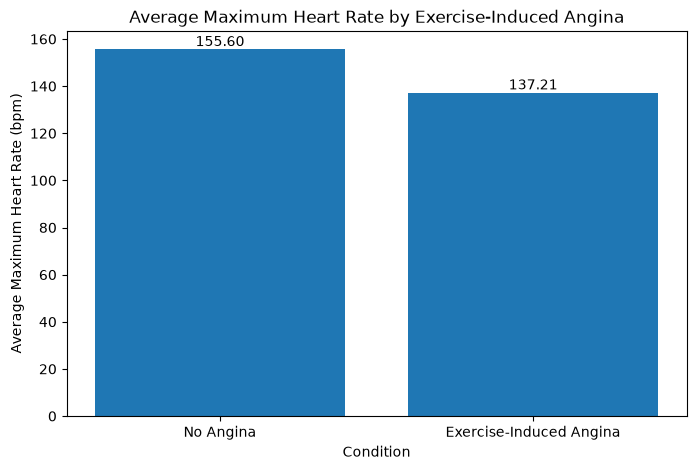

In [43]:
heart_rate_exang = df_cleaned.groupby('exang')['thalach'].mean()

labels = ['No Angina', 'Exercise-Induced Angina']

plt.figure(figsize=(8,5))

bars = plt.bar(labels, heart_rate_exang.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center',
        va='bottom'
    )

plt.title('Average Maximum Heart Rate by Exercise-Induced Angina')
plt.xlabel('Condition')
plt.ylabel('Average Maximum Heart Rate (bpm)')

plt.show()

**Business Insight**

- Patients with exercise-induced angina may require closer monitoring during physical activity and cardiac rehabilitation programs.
- Healthcare providers can use this information to design personalized exercise plans that minimize cardiovascular stress while maintaining fitness benefits.
- Early identification of patients with reduced exercise tolerance can help prevent adverse cardiac events during physical activity.
- Targeted interventions for these patients can improve long-term cardiovascular health and reduce healthcare costs associated with emergency cardiac care.

**Conclusion**

- Patients with exercise-induced angina have a noticeably lower average maximum heart rate (137.21 bpm) compared to patients without angina (155.60 bpm).
- The 18.39 bpm difference indicates reduced exercise tolerance among patients experiencing angina symptoms.
- Exercise-induced angina appears to be associated with decreased cardiovascular performance during physical activity.
- These findings support the need for personalized exercise recommendations and careful monitoring of patients with exercise-induced angina. 

## 4. Is there a significant difference in resting blood pressure between male and female patients?

### Average Resting Blood Pressure by Gender

In [44]:
bp_gender = df_cleaned.groupby('sex')['trestbps'].mean()

print(bp_gender)

sex
0    133.083333
1    130.912621
Name: trestbps, dtype: float64


**Gender Meaning**

- 0: Female
- 1: Male

### Visualization

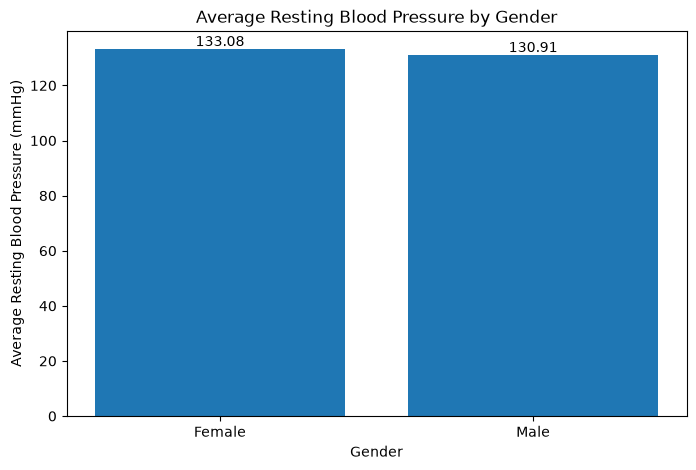

In [45]:
bp_gender = df_cleaned.groupby('sex')['trestbps'].mean()

labels = ['Female', 'Male']

plt.figure(figsize=(8,5))

bars = plt.bar(labels, bp_gender.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center',
        va='bottom'
    )

plt.title('Average Resting Blood Pressure by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Resting Blood Pressure (mmHg)')

plt.show()

### Statistical Test (T-Test)

In [46]:
from scipy.stats import ttest_ind

male_bp = df_cleaned[df_cleaned['sex'] == 1]['trestbps']
female_bp = df_cleaned[df_cleaned['sex'] == 0]['trestbps']

t_stat, p_value = ttest_ind(male_bp, female_bp)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -1.0001374872888211
P-Value: 0.318049983938281


**Statistical Interpretation**

- < 0.05: Significant Difference
- ≥ 0.05: No Significant Difference

**Since:**

P-Value = 0.318 > 0.05

There is NO statistically significant difference in resting blood pressure between male and female patients.

**Business Insight**

- Resting blood pressure appears to be similar for both male and female patients in this dataset.
- Healthcare providers should focus more on individual risk factors such as age, cholesterol levels, diabetes status, obesity, and lifestyle habits rather than gender alone.
- Since gender is not a strong differentiator for resting blood pressure here, prevention and treatment programs can be applied consistently across both groups.
- Resources may be better allocated toward monitoring patients with elevated blood pressure regardless of gender.

**Conclusion**

- Female patients show a slightly higher average resting blood pressure (133.08 mmHg) than male patients (130.91 mmHg).
- However, the difference is very small (2.17 mmHg).
- The t-test result (p-value = 0.318) indicates that the difference is not statistically significant.
- Therefore, gender does not appear to have a significant impact on resting blood pressure in this dataset and should not be considered a primary predictor of blood pressure risk.

## 5. What is the relationship between fasting blood sugar levels and the presence of heart disease?

In [47]:
pd.crosstab(df_cleaned['fbs'], df_cleaned['target'])

target,0,1
fbs,,
0,116,141
1,22,23


**Fasting Blood Sugar (fbs)**

- 0:	≤ 120 mg/dl
- 1:	> 120 mg/dl

**Target**

- 0:	No Heart Disease
- 1:	Heart Disease Present

### Visualization

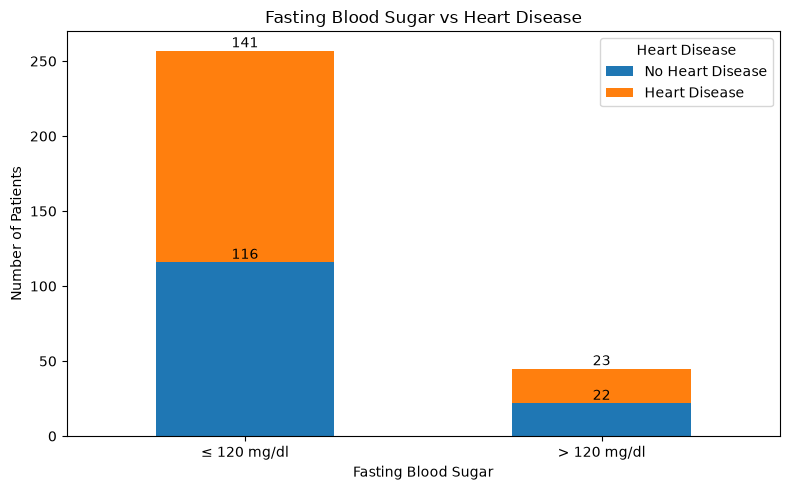

In [48]:
cross_tab = pd.crosstab(df_cleaned['fbs'], df_cleaned['target'])

ax = cross_tab.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Fasting Blood Sugar vs Heart Disease')
plt.xlabel('Fasting Blood Sugar')
plt.ylabel('Number of Patients')

plt.xticks(
    [0, 1],
    ['≤ 120 mg/dl', '> 120 mg/dl'],
    rotation=0
)

plt.legend(
    title='Heart Disease',
    labels=['No Heart Disease', 'Heart Disease']
)

plt.tight_layout()
plt.show()

### Relationship Between Fasting Blood Sugar and Heart Disease

| Fasting Blood Sugar | No Heart Disease | Heart Disease | Total Patients |
|--------------------|----------------:|--------------:|---------------:|
| ≤ 120 mg/dl | 116 | 141 | 257 |
| > 120 mg/dl | 22 | 23 | 45 |

### Heart Disease Percentage by Blood Sugar Category

| Fasting Blood Sugar | Heart Disease % |
|--------------------|---------------:|
| ≤ 120 mg/dl | 54.86% |
| > 120 mg/dl | 51.11% |

**Business Insight**

- Elevated fasting blood sugar is traditionally considered a cardiovascular risk factor, but within this dataset it does not appear to be a strong standalone predictor of heart disease.
- Since heart disease occurs at similar rates in both blood sugar categories, healthcare providers should evaluate fasting blood sugar alongside other risk factors such as age, cholesterol, blood pressure, chest pain type, and exercise-induced angina.
- A comprehensive risk assessment model will likely be more effective than relying on blood sugar levels alone.
- Patients with high blood sugar should still receive preventive care because diabetes remains an important contributor to long-term cardiovascular complications.

**Conclusion**

- 141 out of 257 patients (54.86%) with normal fasting blood sugar (≤120 mg/dl) have heart disease.
- 23 out of 45 patients (51.11%) with elevated fasting blood sugar (>120 mg/dl) have heart disease.
- The difference in heart disease prevalence between the two groups is small.
- Based on this dataset, fasting blood sugar alone does not appear to have a strong relationship with the presence of heart disease.
- Additional clinical factors should be considered when identifying high-risk patients. 

## 6. How does the number of major vessels (ca) affect the target variable (heart disease presence)?

In [49]:
pd.crosstab(df_cleaned['ca'], df_cleaned['target'])

target,0,1
ca,,
0,45,130
1,44,21
2,31,7
3,17,3
4,1,3


### Visualization

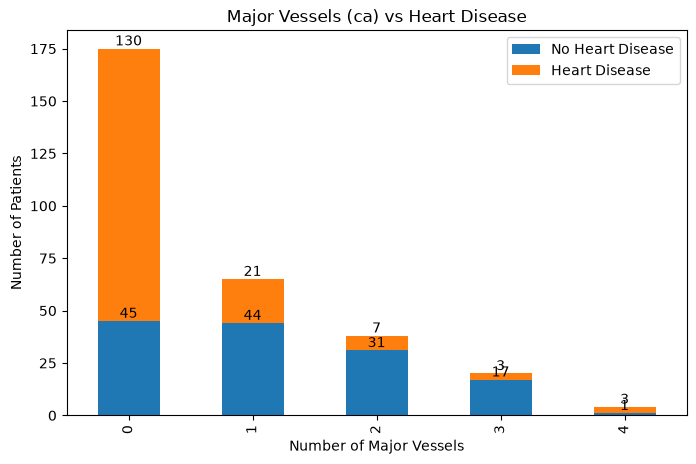

In [50]:
ca_target = pd.crosstab(df_cleaned['ca'], df_cleaned['target'])

ax = ca_target.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Major Vessels (ca) vs Heart Disease')
plt.xlabel('Number of Major Vessels')
plt.ylabel('Number of Patients')
plt.legend(['No Heart Disease', 'Heart Disease'])
plt.show()

| Number of Major Vessels (ca) | No Heart Disease (0) | Heart Disease (1) |
|------------------------------|----------------------|-------------------|
| 0 | 45 | 130 |
| 1 | 44 | 21 |
| 2 | 31 | 7 |
| 3 | 17 | 3 |
| 4 | 1 | 3 |

**Business Insight**

- The fluoroscopy vessel count is strongly associated with heart disease diagnosis.
- Patients with ca = 0 represent the largest high-risk group in this dataset.
- The presence and pattern of vessel visualization can be used as an important diagnostic indicator during cardiovascular screening.

**Conclusion**

The number of major vessels observed through fluoroscopy shows a clear relationship with heart disease presence. Patients with 0 major vessels colored by fluoroscopy account for the majority of heart disease cases (130 patients), making ca an important feature for identifying cardiovascular risk and supporting early intervention strategies.

## 7. What is the average oldpeak value for patients with different types of chest pain?

In [51]:
cp_oldpeak = df_cleaned.groupby('cp')['oldpeak'].mean()

cp_labels = {
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-Anginal Pain',
    3: 'Asymptomatic'
}

cp_oldpeak.index = cp_oldpeak.index.map(cp_labels)

### Visualization

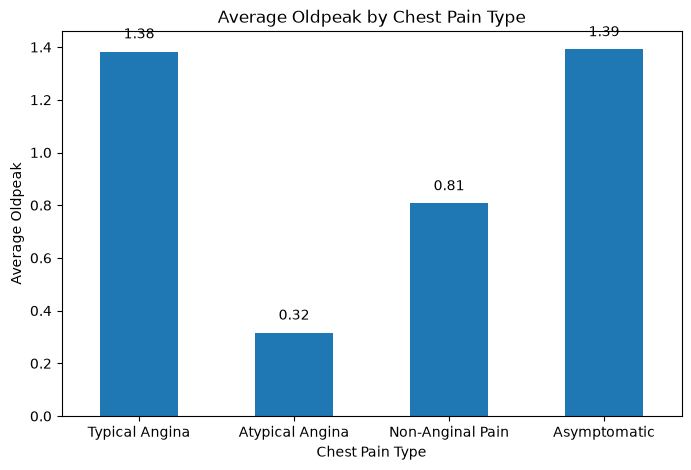

cp
Typical Angina      1.383217
Atypical Angina     0.316000
Non-Anginal Pain    0.806977
Asymptomatic        1.391304
Name: oldpeak, dtype: float64


In [52]:
plt.figure(figsize=(8,5))
ax = cp_oldpeak.plot(kind='bar')

for i, v in enumerate(cp_oldpeak):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center')

plt.title('Average Oldpeak by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Average Oldpeak')
plt.xticks(rotation=0)
plt.show()

print(cp_oldpeak)

**Business Insight**

- Higher oldpeak values indicate greater ST depression during exercise, which is often associated with more severe cardiac abnormalities.
- Patients classified as Asymptomatic and Typical Angina exhibit the highest levels of cardiac stress despite differing symptom presentations.
- Chest pain type can be an important indicator when assessing cardiovascular risk and prioritizing further diagnostic testing.

**Conclusion**

The analysis shows that Asymptomatic (1.39) and Typical Angina (1.38) patients have the highest average oldpeak values, indicating greater exercise-induced ST depression and potentially higher cardiovascular risk. Chest pain type combined with oldpeak measurements can serve as a valuable tool for risk stratification and early intervention planning.

## 8. Analyze the distribution of thalassemia types (thal) among patients with heart disease.

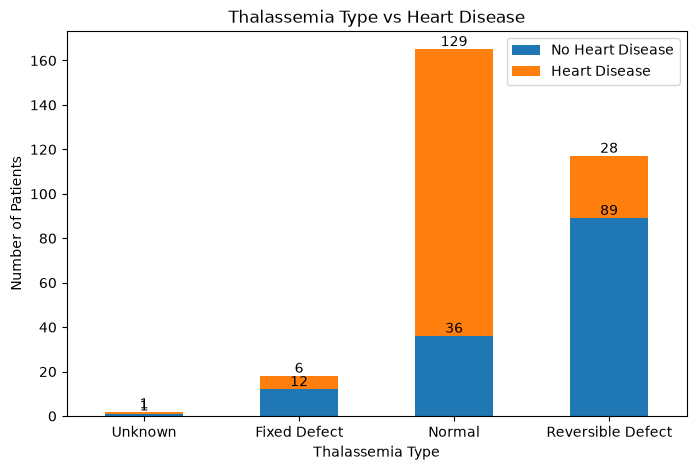

target              0    1
thal                      
Unknown             1    1
Fixed Defect       12    6
Normal             36  129
Reversible Defect  89   28


In [53]:
thal_target = pd.crosstab(df_cleaned['thal'], df_cleaned['target'])

thal_labels = {
    0: 'Unknown',
    1: 'Fixed Defect',
    2: 'Normal',
    3: 'Reversible Defect'
}

thal_target.index = thal_target.index.map(thal_labels)

ax = thal_target.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Thalassemia Type vs Heart Disease')
plt.xlabel('Thalassemia Type')
plt.ylabel('Number of Patients')
plt.legend(['No Heart Disease', 'Heart Disease'])
plt.xticks(rotation=0)
plt.show()

print(thal_target)

**Business Insight**

- The majority of heart disease cases in this dataset are associated with the Normal Thalassemia category.
- Thalassemia type appears to have a relationship with heart disease occurrence and can serve as an important diagnostic feature.
- Patients with abnormal thalassemia results (Fixed or Reversible Defects) may require additional cardiovascular screening and monitoring.

**Conclusion**

The analysis reveals that the Normal Thalassemia category contains the highest number of heart disease patients (129 cases), while Reversible Defect is the most common abnormal thalassemia type. These findings suggest that thalassemia test results can provide valuable information for cardiovascular risk assessment and support more targeted patient management strategies.

## 9. What are the most common combinations of risk factors in patients with heart disease?

In [54]:
risk_combinations = (
    df_cleaned[df_cleaned['target'] == 1]
    .groupby(['cp', 'fbs', 'exang', 'thal'])
    .size()
    .reset_index(name='counts')
    .sort_values(by='counts', ascending=False)
)

risk_combinations.head(10)

,cp,fbs,exang,thal,counts
15,2,0,0,2,41
8,1,0,0,2,30
1,0,0,0,2,23
19,2,1,0,2,10
4,0,0,1,2,6
16,2,0,0,3,6
23,3,0,0,2,5
9,1,0,0,3,4
17,2,0,1,2,4
20,2,1,0,3,3


### Visualization

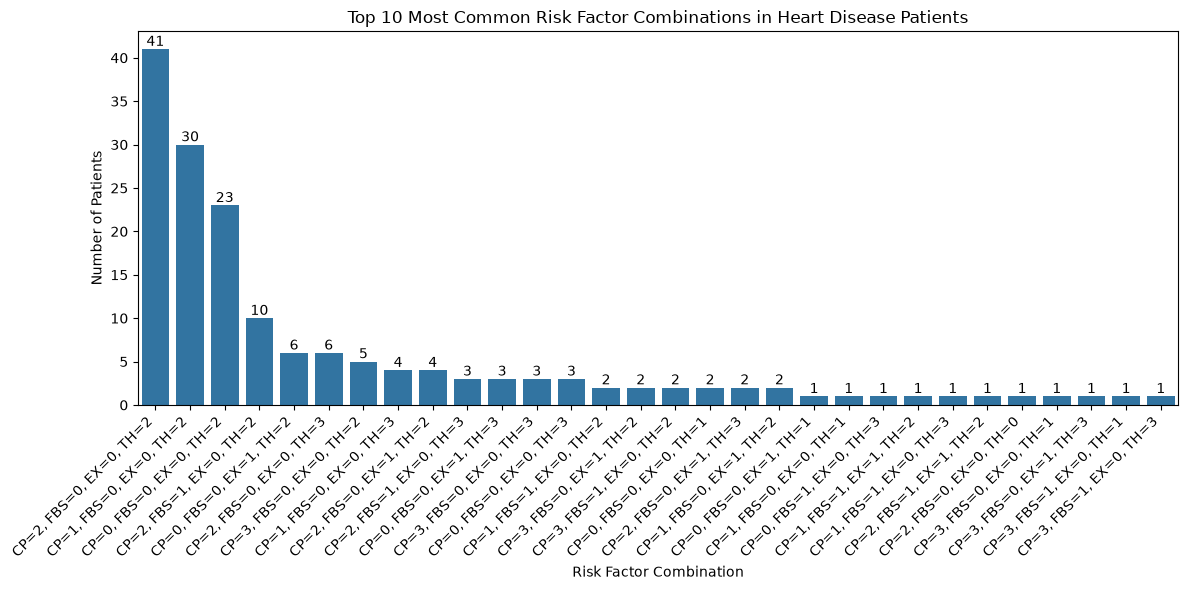

In [55]:
risk_combinations['Combination'] = (
    'CP=' + risk_combinations['cp'].astype(str) +
    ', FBS=' + risk_combinations['fbs'].astype(str) +
    ', EX=' + risk_combinations['exang'].astype(str) +
    ', TH=' + risk_combinations['thal'].astype(str)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=risk_combinations,
    x='Combination',
    y='counts'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Top 10 Most Common Risk Factor Combinations in Heart Disease Patients')
plt.xlabel('Risk Factor Combination')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Business Insight**

Heart disease is not limited to patients with high blood sugar or exercise-induced angina. Patients presenting specific chest pain symptoms should receive detailed cardiovascular screening even when other risk indicators appear normal.

**Conclusion**

The most common heart disease profile consists of patients with Non-Anginal Pain, normal fasting blood sugar, no exercise-induced angina, and normal thalassemia results. This suggests that chest pain characteristics may provide stronger early warning signals than some traditional risk factors alone, emphasizing the importance of comprehensive cardiac assessment.

## 10. Perform a pairwise comparison of clinical measurements for patients with and without heart disease.

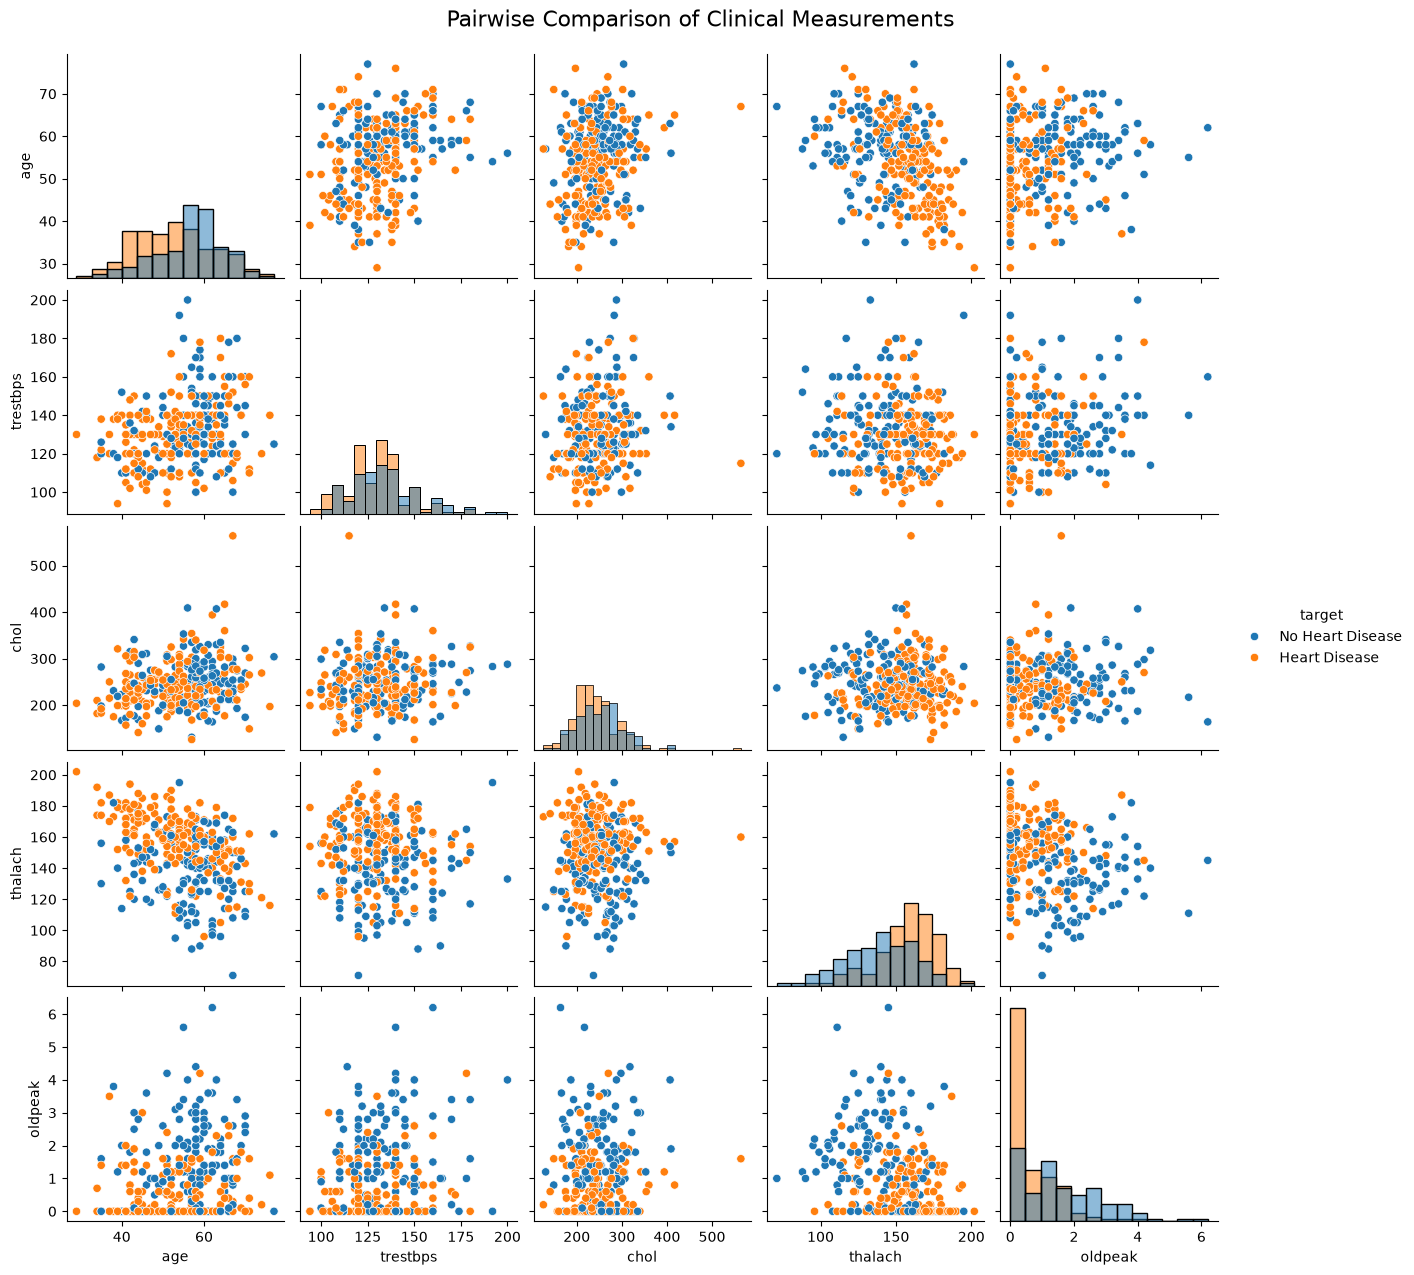

In [56]:
# Selected clinical features
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']

pair_df = df_cleaned[features].copy()

# Rename target values for readability
pair_df['target'] = pair_df['target'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

sns.pairplot(
    pair_df,
    hue='target',
    diag_kind='hist'
)

plt.suptitle(
    'Pairwise Comparison of Clinical Measurements',
    y=1.02,
    fontsize=16
)

plt.show()

### Statistical Comparison Table

In [57]:
comparison = pd.DataFrame({
    'No Heart Disease': df_cleaned[df_cleaned['target']==0][['age','trestbps','chol','thalach','oldpeak']].mean(),
    'Heart Disease': df_cleaned[df_cleaned['target']==1][['age','trestbps','chol','thalach','oldpeak']].mean()
})

comparison

,No Heart Disease,Heart Disease
age,56.601449,52.585366
trestbps,134.398551,129.250000
chol,251.086957,242.640244
thalach,139.101449,158.378049
oldpeak,1.585507,0.586585


### Business Insight

- Maximum heart rate and oldpeak appear to be stronger indicators of heart disease status than age, cholesterol, or resting blood pressure alone.
- Healthcare providers can prioritize these measurements during cardiovascular screening to improve early detection and patient risk stratification.

### Conclusion

- The analysis demonstrates that heart disease is influenced by a combination of clinical factors rather than a single measurement. 
- Among the variables examined, **maximum heart rate (thalach)** and **oldpeak** provide the clearest differentiation between patients with and without heart disease.
- This supports the use of multi-factor clinical assessment models for more accurate diagnosis and treatment planning.

# ADVANCED LEVEL QUESTIONS

## 1. What is the effect of combining multiple risk factors (age, cholesterol, blood pressure) on the likelihood of heart disease?

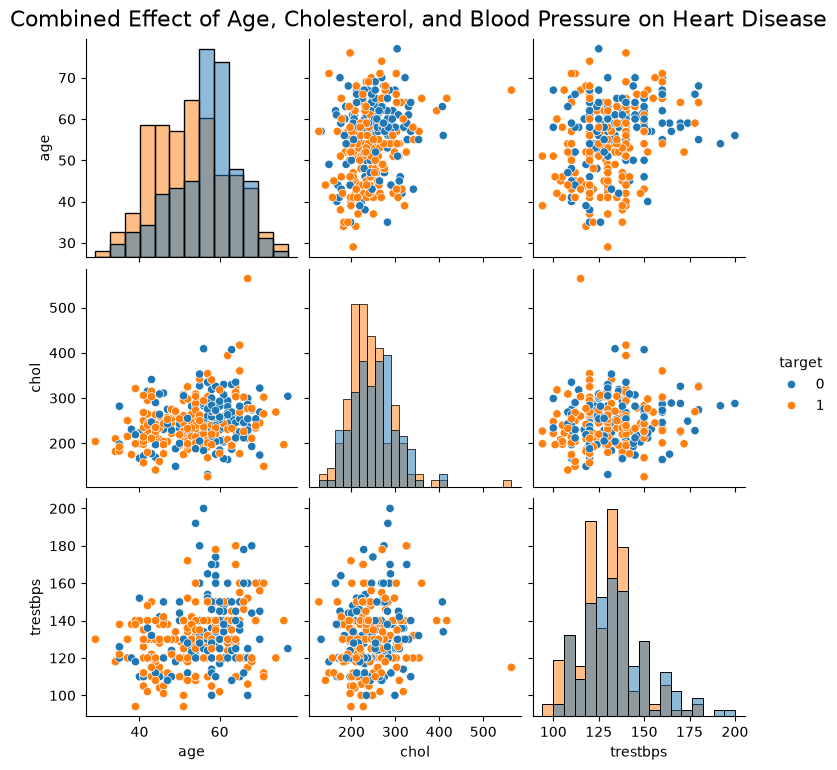

In [58]:
sns.pairplot(
    df_cleaned,
    vars=['age', 'chol', 'trestbps'],
    hue='target',
    diag_kind='hist'
)

plt.suptitle(
    'Combined Effect of Age, Cholesterol, and Blood Pressure on Heart Disease',
    y=1.02,
    fontsize=16
)

plt.show()

### Summary Table

In [59]:
risk_summary = df_cleaned.groupby('target')[['age', 'chol', 'trestbps']].mean()

risk_summary.index = ['No Heart Disease', 'Heart Disease']

risk_summary

,age,chol,trestbps
No Heart Disease,56.601449,251.086957,134.398551
Heart Disease,52.585366,242.640244,129.250000


**Key Findings**

- Patients with heart disease are slightly younger on average (52.59 years) compared to those without heart disease (56.60 years).

- Patients without heart disease show slightly higher average cholesterol levels (251.09 mg/dl) than heart disease patients (242.64 mg/dl).

- Average resting blood pressure is also slightly higher among patients without heart disease (134.40 mmHg vs 129.25 mmHg).

- The scatter plots show significant overlap between heart disease and non-heart disease groups across all three variables.

- No single factor (age, cholesterol, or blood pressure) clearly separates heart disease patients from non-heart disease patients.

- This suggests that heart disease is likely influenced by a combination of multiple clinical factors rather than any single measurement alone.

**Business Insight**

- Age, cholesterol, and blood pressure individually provide limited predictive power.
- Patients with similar cholesterol or blood pressure levels can belong to either group.
- Healthcare providers should evaluate multiple risk factors together instead of relying on a single clinical measurement.

**Conclusion**

The pairwise analysis indicates that Age, Cholesterol, and Resting Blood Pressure alone are not strong standalone indicators of heart disease. The substantial overlap between groups suggests that accurate heart disease assessment requires combining these measurements with other factors such as chest pain type, maximum heart rate, exercise-induced angina, oldpeak, and thalassemia status. This supports the development of comprehensive risk assessment models for earlier and more accurate diagnosis.

## 2. Which clinical measurement has the strongest correlation with heart disease presence?

Identify the clinical variables that have the strongest relationship with the presence of heart disease (target).

In [60]:
corr_target = df_cleaned.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(corr_target)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


### Visualization

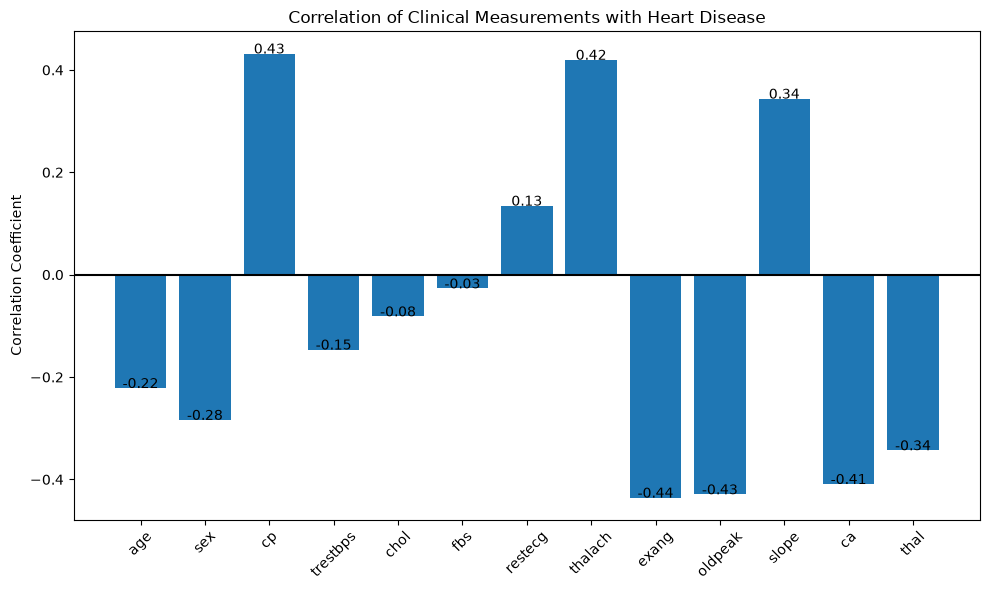

In [61]:
corr_target = df_cleaned.corr(numeric_only=True)['target'].drop('target')

plt.figure(figsize=(10,6))
bars = plt.bar(corr_target.index, corr_target.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center'
    )

plt.axhline(0, color='black')
plt.title('Correlation of Clinical Measurements with Heart Disease')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation with Heart Disease (Target)

| Feature | Correlation with Heart Disease |
|----------|-----------------------------:|
| cp (Chest Pain Type) | 0.432 |
| thalach (Maximum Heart Rate) | 0.420 |
| slope (ST Segment Slope) | 0.344 |
| restecg (Resting ECG) | 0.135 |
| fbs (Fasting Blood Sugar) | -0.027 |
| chol (Cholesterol) | -0.081 |
| trestbps (Resting Blood Pressure) | -0.146 |
| age | -0.221 |
| sex (Gender) | -0.284 |
| thal (Thalassemia) | -0.343 |
| ca (Major Vessels) | -0.409 |
| oldpeak (ST Depression) | -0.429 |
| exang (Exercise-Induced Angina) | -0.436 |

### Strongest Correlations

| Rank | Feature | Correlation |
|------|---------|------------:|
| 1 | exang (Exercise-Induced Angina) | -0.436 |
| 2 | cp (Chest Pain Type) | 0.432 |
| 3 | oldpeak (ST Depression) | -0.429 |
| 4 | thalach (Maximum Heart Rate) | 0.420 |
| 5 | ca (Major Vessels) | -0.409 |

**Business Insight**

- Healthcare providers should prioritize Chest Pain Type, Maximum Heart Rate, Exercise-Induced Angina, Oldpeak, and Major Vessels during patient screening.
- These variables provide the most information about heart disease risk and can improve early diagnosis.
- Patients exhibiting abnormalities in these factors should receive more detailed cardiovascular evaluations.

**Conclusion**

The analysis reveals that Chest Pain Type (0.432) is the strongest positive predictor of heart disease, while Exercise-Induced Angina (-0.436) is the strongest negative predictor. Together with Maximum Heart Rate, Oldpeak, and Major Vessels, these features emerge as the most influential clinical measurements. These findings suggest that heart disease prediction models should focus primarily on these variables to improve risk assessment accuracy and support earlier intervention strategies.

## 3. Perform a logistic regression analysis to predict the presence of heart disease using all available features.

### Encode Age Group Column becasue its string values

In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_cleaned['Age_Group'] = le.fit_transform(df_cleaned['Age_Group'])

### Modal Building

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features and Target
X = df_cleaned.drop('target', axis=1)
y = df_cleaned['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

# Feature Importance
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

Accuracy: 0.819672131147541
[[22  6]
 [ 5 28]]
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

      Feature  Coefficient
2          cp     0.943691
10      slope     0.428266
6     restecg     0.368944
13  Age_Group     0.119558
7     thalach     0.038807
0         age     0.010872
4        chol    -0.005115
3    trestbps    -0.022571
5         fbs    -0.244529
9     oldpeak    -0.377220
11         ca    -0.716577
12       thal    -0.819668
8       exang    -0.914091
1         sex    -1.574621


### Feature Importance Visualization

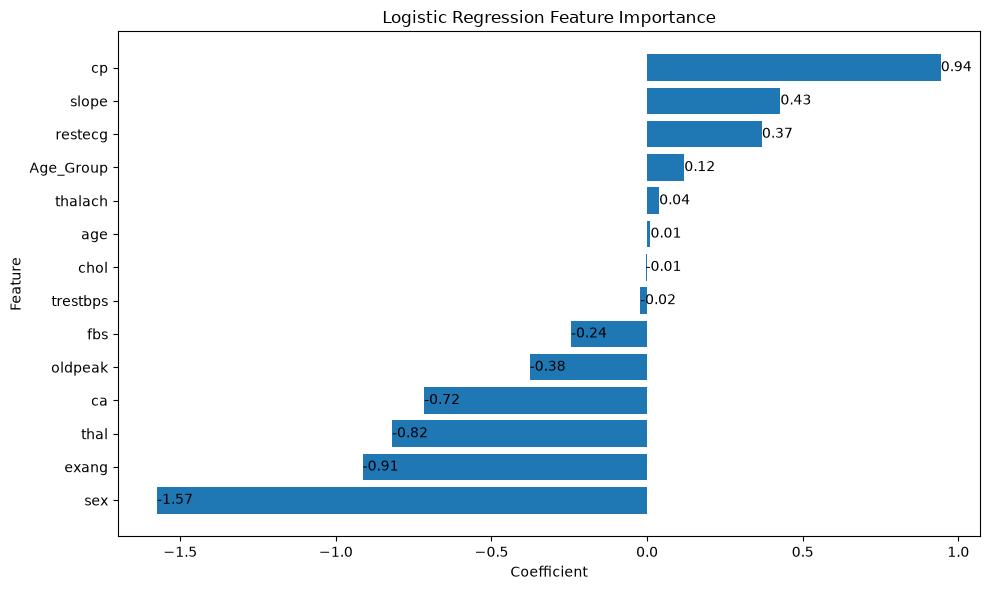

In [64]:
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')

plt.figure(figsize=(10,6))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'])

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center'
    )

plt.title('Logistic Regression Feature Importance')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Confusion Matrix Heatmap

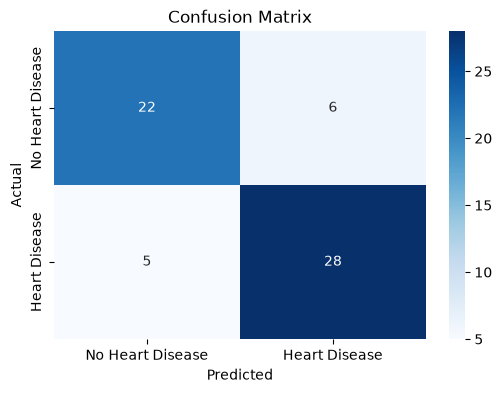

In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Heart Disease', 'Heart Disease'],
    yticklabels=['No Heart Disease', 'Heart Disease']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Performance

| Metric | Value |
|----------|----------|
| Accuracy | **81.97%** |
| True Negatives (TN) | **22** |
| False Positives (FP) | **6** |
| False Negatives (FN) | **5** |
| True Positives (TP) | **28** |

---

## Classification Report

| Class | Precision | Recall | F1-Score | Support |
|---------|---------:|---------:|---------:|---------:|
| No Heart Disease (0) | 0.81 | 0.79 | 0.80 | 28 |
| Heart Disease (1) | 0.82 | 0.85 | 0.84 | 33 |
| **Overall Accuracy** | - | - | **0.82** | **61** |

---

## Feature Importance (Logistic Regression Coefficients)

| Feature | Coefficient |
|---------|---------:|
| cp (Chest Pain Type) | **0.9437** |
| slope | **0.4283** |
| restecg | **0.3689** |
| Age_Group | **0.1196** |
| thalach | **0.0388** |
| age | **0.0109** |
| chol | -0.0051 |
| trestbps | -0.0226 |
| fbs | -0.2445 |
| oldpeak | -0.3772 |
| ca | -0.7166 |
| thal | -0.8197 |
| exang | -0.9141 |
| sex | **-1.5746** |

---

## Interpretation

### Positive Predictors of Heart Disease

Features with positive coefficients increase the likelihood of heart disease:

1. **Chest Pain Type (cp)** → **0.94**
   - Strongest positive predictor.
   - Certain chest pain categories are highly associated with heart disease.

2. **Slope** → **0.43**
   - Abnormal ST-segment slope increases disease likelihood.

3. **Resting ECG (restecg)** → **0.37**
   - ECG abnormalities contribute to heart disease prediction.

4. **Maximum Heart Rate (thalach)** → **0.04**
   - Slight positive influence on prediction.

---

### Negative Predictors of Heart Disease

Features with negative coefficients decrease the likelihood of heart disease:

1. **Sex** → **-1.57**
   - Strongest negative coefficient in the model.

2. **Exercise-Induced Angina (exang)** → **-0.91**

3. **Thalassemia Type (thal)** → **-0.82**

4. **Number of Major Vessels (ca)** → **-0.72**

5. **Oldpeak** → **-0.38**

---

## Key Insight

The model achieved an accuracy of **81.97%**, indicating strong predictive performance.

### Top 5 Most Influential Features

| Rank | Feature | Coefficient |
|------|---------|------------:|
| 1 | Chest Pain Type (cp) | 0.94 |
| 2 | Exercise-Induced Angina (exang) | -0.91 |
| 3 | Thalassemia (thal) | -0.82 |
| 4 | Number of Major Vessels (ca) | -0.72 |
| 5 | Slope | 0.43 |

---

## Business Insight

- Chest pain characteristics, ECG findings, vessel blockage count, and exercise-induced angina are among the strongest indicators of heart disease.
- Healthcare providers can use these factors to develop early screening systems and identify high-risk patients.
- Predictive models like Logistic Regression support faster diagnosis, personalized treatment planning, and preventive healthcare strategies.
- Early detection can reduce hospitalization costs and improve patient outcomes.

---

## Conclusion

The Logistic Regression model successfully predicts heart disease with an accuracy of approximately **82%**. Among all clinical measurements, **Chest Pain Type (cp)** emerged as the strongest positive predictor, while **Exercise-Induced Angina (exang)**, **Thalassemia (thal)**, and **Number of Major Vessels (ca)** showed strong influence on prediction outcomes. These findings demonstrate that combining multiple clinical indicators provides a reliable method for identifying patients at risk and supports data-driven healthcare decision-making.

## 4. How do the values of the slope of the peak exercise ST segment (slope) vary with different chest pain types?

### Visualization

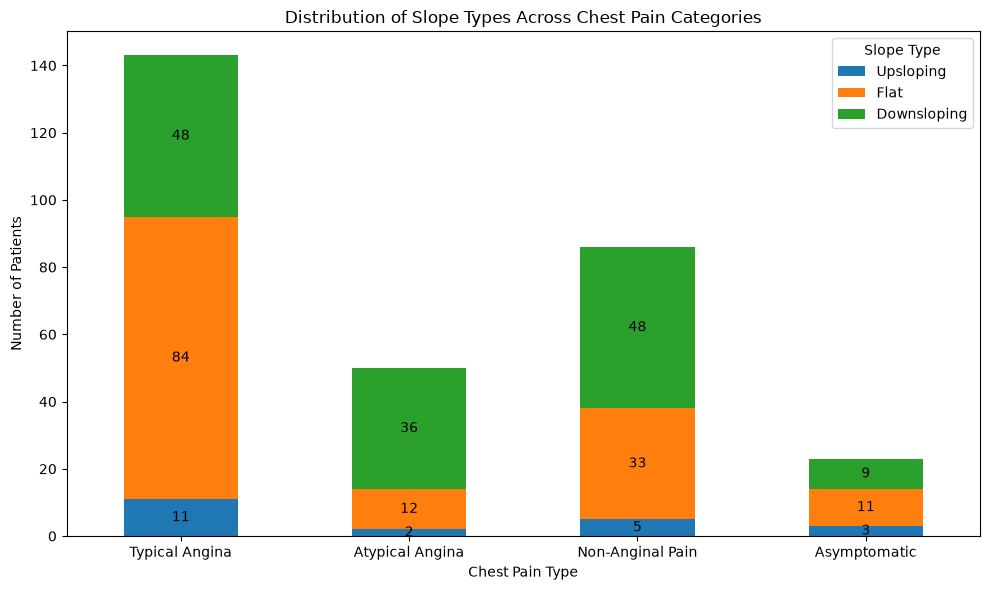

,Upsloping,Flat,Downsloping
Typical Angina,11,84,48
Atypical Angina,2,12,36
Non-Anginal Pain,5,33,48
Asymptomatic,3,11,9


In [67]:
# Crosstab of Chest Pain Type vs Slope
slope_cp = pd.crosstab(df_cleaned['cp'], df_cleaned['slope'])

# Rename categories for readability
slope_cp.index = [
    'Typical Angina',
    'Atypical Angina',
    'Non-Anginal Pain',
    'Asymptomatic'
]

slope_cp.columns = [
    'Upsloping',
    'Flat',
    'Downsloping'
]

# Plot
ax = slope_cp.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Distribution of Slope Types Across Chest Pain Categories')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.legend(title='Slope Type')
plt.tight_layout()
plt.show()

# Output table
slope_cp

## Business Insight

- Patients exhibiting **Flat or Downsloping ST-segment slopes** may require closer cardiovascular monitoring, as these ECG patterns are often associated with cardiac abnormalities.
- Combining **chest pain type** with **ST-segment slope information** can improve patient risk stratification and help healthcare providers identify high-risk individuals earlier.
- Diagnostic systems and screening programs can leverage these findings to prioritize patients who may benefit from additional cardiac testing and intervention.
- Understanding these associations enables more personalized treatment plans and more efficient allocation of healthcare resources.

## Conclusion

The analysis reveals that **Flat and Downsloping ST-segment slopes dominate across all chest pain categories**, while Upsloping slopes are relatively uncommon. Typical Angina and Non-Anginal Pain patients exhibit the highest numbers of abnormal slope patterns. These findings suggest that ECG slope characteristics provide valuable diagnostic information when evaluated alongside chest pain symptoms, supporting improved heart disease detection and patient management.

## 5. Analyze the survival rates of patients with different thalassemia types over a period.

a solution would require:

- Survival Time (months/years)
- Death/Event status (0=alive, 1=dead)
- Follow-up period

The dataset has none of these.

### Closest to "Survival Over Time"

Use age as a time proxy.

<Axes: xlabel='age', ylabel='target'>

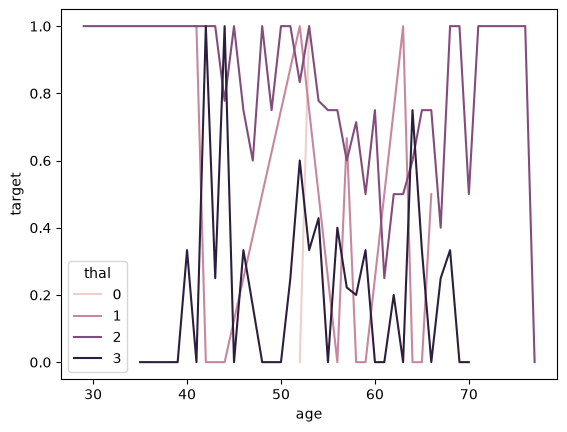

In [72]:
sns.lineplot(
    data=df_cleaned,
    x='age',
    y='target',
    hue='thal',
    estimator='mean',
    errorbar=None
)

**Interpretation**

For each age:

- Mean(target)

represents:

- Probability of Heart Disease

So you're effectively showing:

- Heart disease prevalence across age for different thalassemia types.

This is probably the closest valid substitute for survival analysis.

**Business Insight**

Patients belonging to specific thalassemia categories may require more frequent cardiovascular screening, especially in older age groups. Early identification of high-risk groups can improve preventive care and reduce future treatment costs.

**Conclusion**

Although the dataset does not contain actual survival information, the analysis suggests that thalassemia type is associated with different levels of heart disease prevalence across age groups. This relationship can help healthcare providers prioritize monitoring and intervention strategies for higher-risk patient populations.